<a href="https://colab.research.google.com/github/xiomara-udea/garbage-classification-dataset/blob/main/01_exploraci%C3%B3n_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EXPLORACIÓN DE DATOS - GARBAGE CLASSIFICATION**

### **Descarga del Dataset**

In [ ]:
!kaggle datasets download -d namanjain001/garbage-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/namanjain001/garbage-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 87.3M/87.3M [00:03<00:00, 23.6MB/s]



### **Descompresión**

In [ ]:
!unzip garbage-classification-dataset.zip

### **Verificar contenido**

In [ ]:
import os
os.listdir()

['.config',
 'garbage-classification-dataset.zip',
 'Final Dataset',
 'sample_data']

### **Explorar la estructura de las carpetas**

In [ ]:
dataset_path = "Final Dataset"
os.listdir(dataset_path)

['trash',
 'cardboard',
 'brown-glass',
 'plastic',
 'battery',
 'biological',
 'metal',
 'white-glass',
 'paper',
 'green-glass']

### **Cantidad de imágenes por clase**

In [ ]:
import os

dataset_path = "Final Dataset"

clases = []
cantidades = []

for clase in os.listdir(dataset_path):
    ruta = os.path.join(dataset_path, clase)

    if os.path.isdir(ruta):
        cantidad = len(os.listdir(ruta))
        print(clase, ":", cantidad)

        clases.append(clase)
        cantidades.append(cantidad)

trash : 666
cardboard : 1000
brown-glass : 666
plastic : 1000
battery : 1000
biological : 1000
metal : 1000
white-glass : 777
paper : 1000
green-glass : 666


### **Gráfica de distribución**

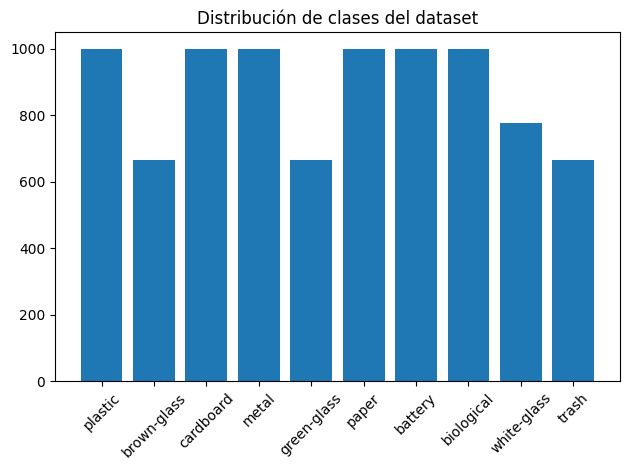

In [ ]:
import matplotlib.pyplot as plt

plt.bar(clases, cantidades)
plt.xticks(rotation=45)
plt.title("Distribución de clases del dataset")
plt.tight_layout()

plt.savefig("grafica_clases.png")
plt.show()

### **Tabla resumen**

In [ ]:
import pandas as pd

df_clases = pd.DataFrame({
    "Clase": clases,
    "Cantidad": cantidades
})

df_clases

,Clase,Cantidad
0,trash,666
1,cardboard,1000
2,brown-glass,666
3,plastic,1000
4,battery,1000
5,biological,1000
6,metal,1000
7,white-glass,777
8,paper,1000
9,green-glass,666


### **Número total de imágenes**

In [ ]:
total_imagenes = sum(cantidades)

print("Total de imágenes:", total_imagenes)

Total de imágenes: 8775


### **Visualización de ejemplos**

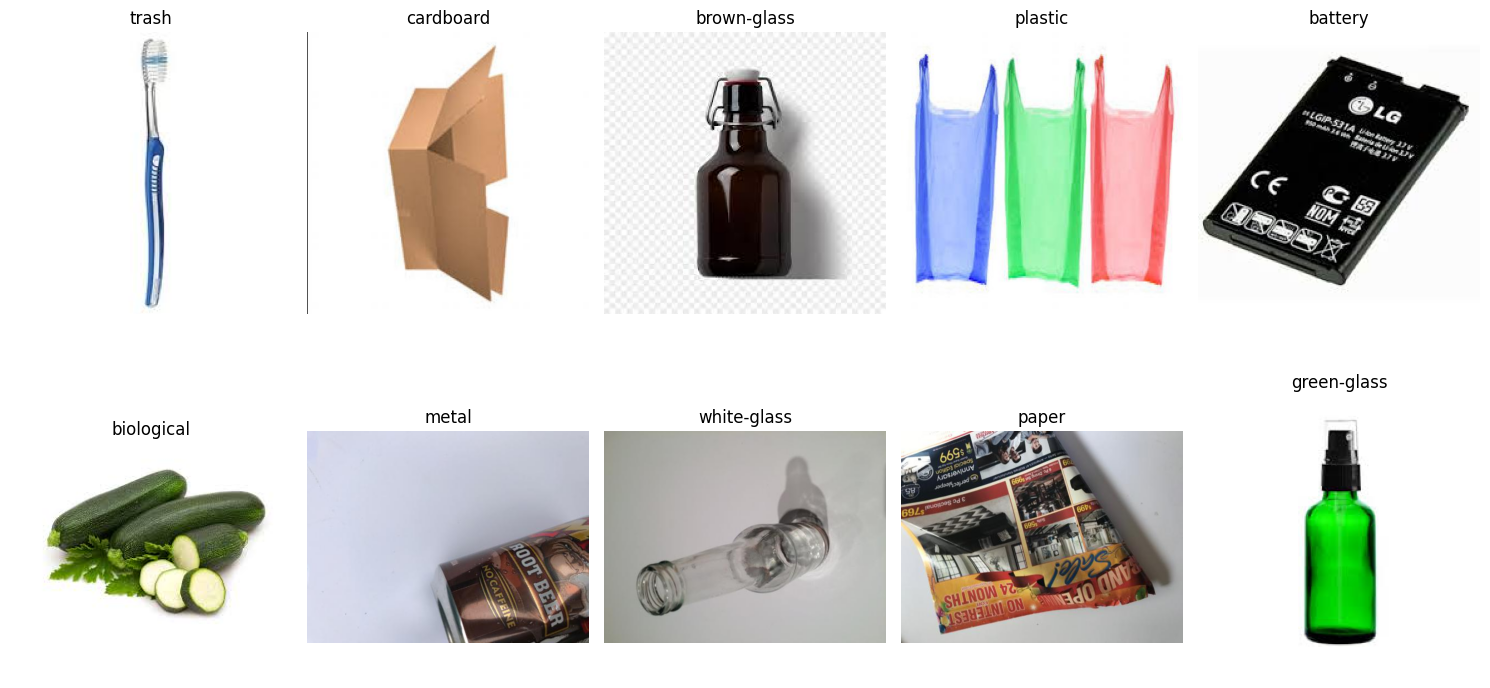

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(15,8))

axes = axes.flatten()

for i, clase in enumerate(os.listdir(dataset_path)):
    carpeta = os.path.join(dataset_path, clase)
    imagen = os.listdir(carpeta)[0]
    ruta_imagen = os.path.join(carpeta, imagen)

    img = Image.open(ruta_imagen)
    axes[i].imshow(img)
    axes[i].set_title(clase)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### **Tamaño de las imágenes**

In [ ]:
from PIL import Image

anchos = []
altos = []

for clase in os.listdir(dataset_path):

    carpeta = os.path.join(dataset_path, clase)

    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        img = Image.open(ruta)
        ancho, alto = img.size
        anchos.append(ancho)
        altos.append(alto)

**Tamaño de las imágenes - histograma de anchos**

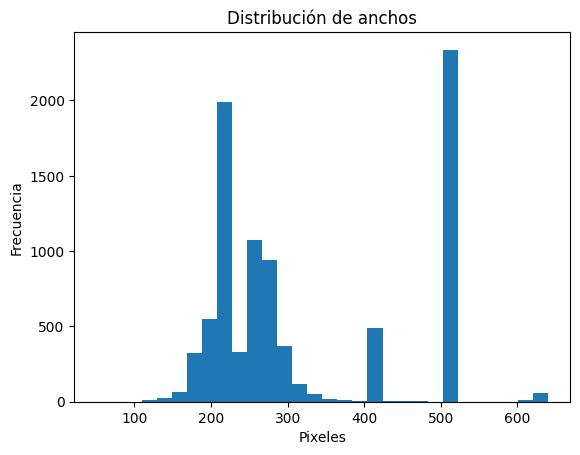

In [ ]:
plt.hist(anchos, bins=30)
plt.title("Distribución de anchos")
plt.xlabel("Pixeles")
plt.ylabel("Frecuencia")
plt.show()

**Tamaño de las imágenes - histograma de altos**

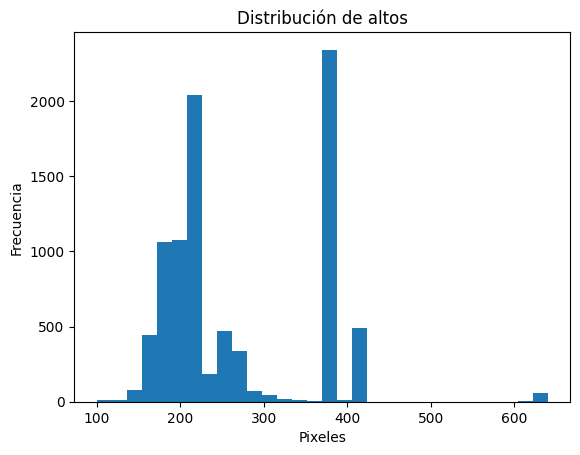

In [ ]:
plt.hist(altos, bins=30)
plt.title("Distribución de altos")
plt.xlabel("Pixeles")
plt.ylabel("Frecuencia")
plt.show()

### **Imágenes por clase**

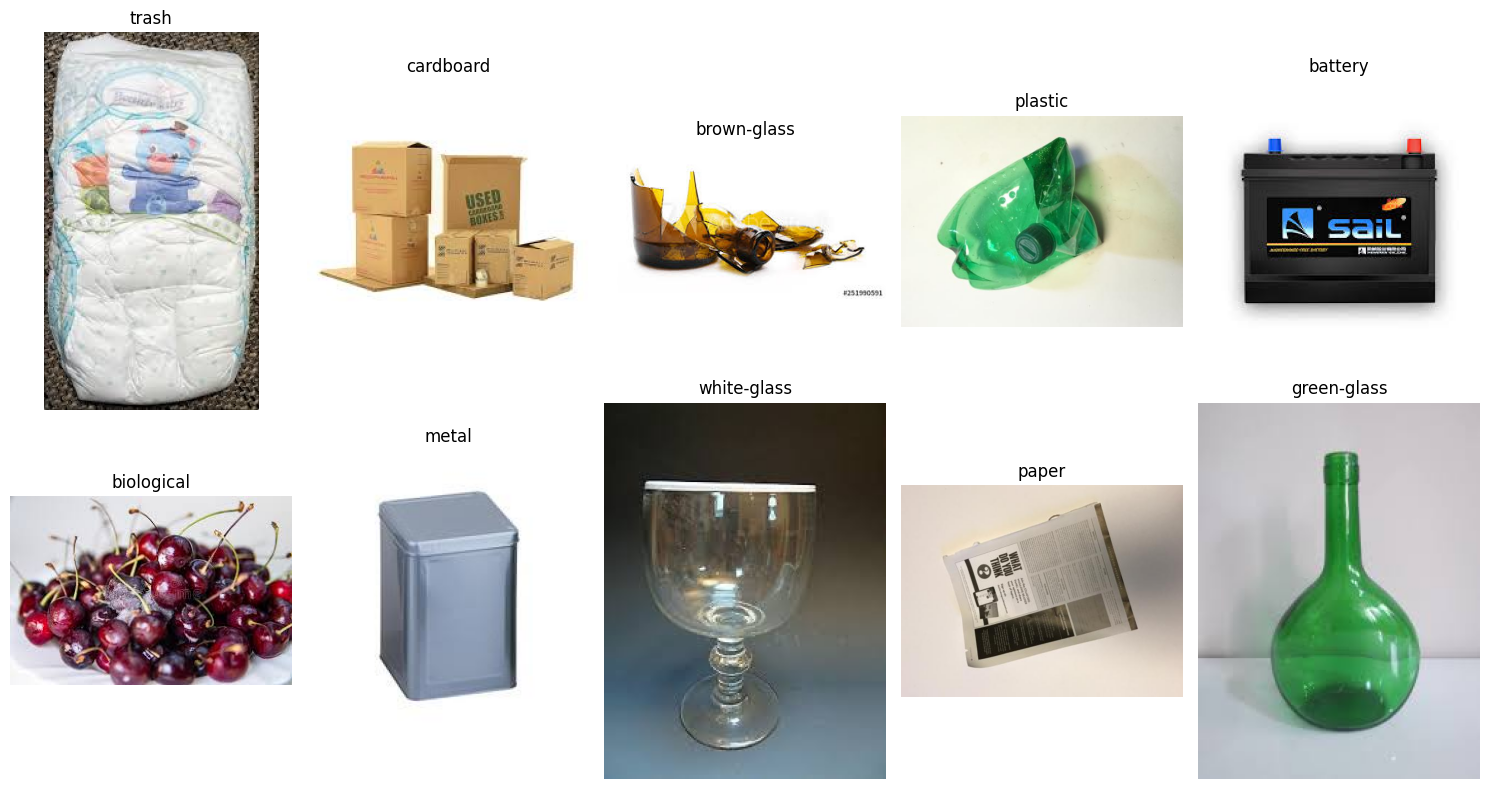

In [ ]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2,5, figsize=(15,8))

for ax, clase in zip(axes.ravel(), clases):

    ruta = os.path.join(dataset_path, clase)

    imagen = random.choice(os.listdir(ruta))

    img = plt.imread(os.path.join(ruta, imagen))

    ax.imshow(img)
    ax.set_title(clase)
    ax.axis("off")

plt.tight_layout()

### **Distribución porcentual**

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Clase": clases,
    "Cantidad": cantidades
})

df["Porcentaje"] = df["Cantidad"] / df["Cantidad"].sum() * 100

df

,Clase,Cantidad,Porcentaje
0,trash,666,7.589744
1,cardboard,1000,11.396011
2,brown-glass,666,7.589744
3,plastic,1000,11.396011
4,battery,1000,11.396011
5,biological,1000,11.396011
6,metal,1000,11.396011
7,white-glass,777,8.854701
8,paper,1000,11.396011
9,green-glass,666,7.589744


# Conclusiones de la exploración de datos

- El dataset contiene 8775 imágenes distribuidas en 10 categorías.
- Existe un ligero desbalance entre clases.
- Las clases Brown-glass, Green-glass y Trash poseen menos imágenes.
- Las imágenes presentan tamaños variables.
- Será necesario realizar redimensionamiento antes del entrenamiento.
- Se utilizará data augmentation para mejorar la generalización de los modelos.